In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("/home/katya/wspace/logs/aruco_odom_gt_0.csv")

In [2]:
print(df.columns.tolist())

['t', 'odom_stamp', 'aruco_stamp', 'marker_center_stamp', 'gt_stamp', 'dt_odom_gt', 'dt_aruco_gt', 'dt_marker_gt', 'odom_x', 'odom_y', 'odom_yaw', 'aruco_frame', 'aruco_x', 'aruco_y', 'aruco_z', 'aruco_yaw', 'marker_center_frame', 'marker_center_x', 'marker_center_y', 'marker_center_z', 'marker_center_yaw', 'gt_frame', 'gt_x', 'gt_y', 'gt_z', 'gt_yaw']


theta_align_xy [rad] = 0.0
theta_align_xy [deg] = 0.0
yaw_bias [rad] = 0.16105304696058087
yaw_bias [deg] = 9.227659868563535


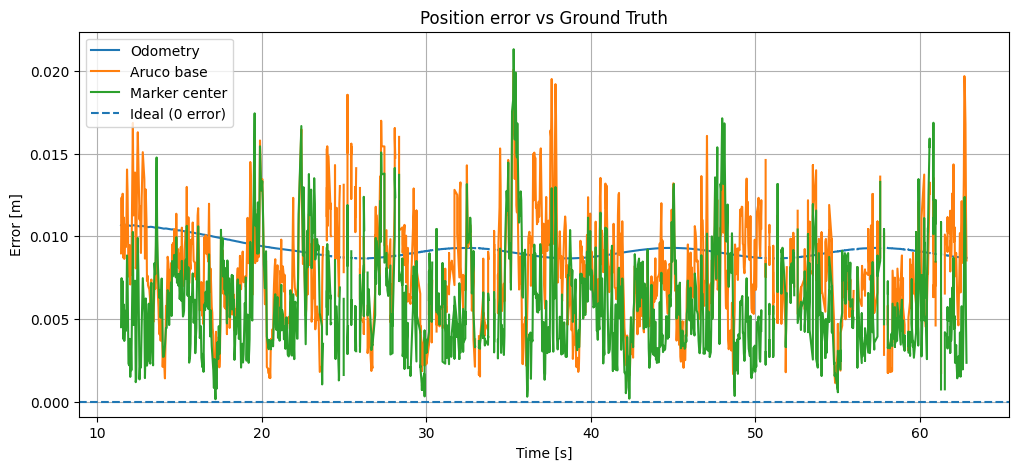

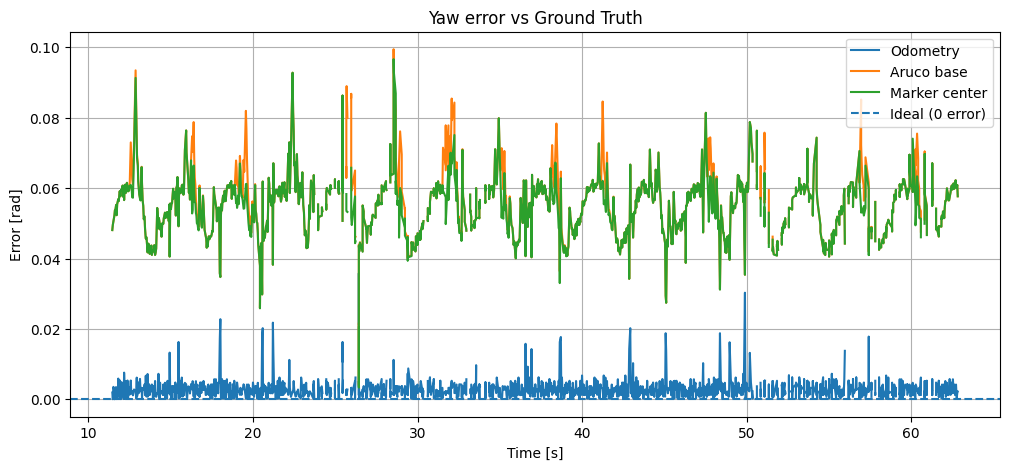

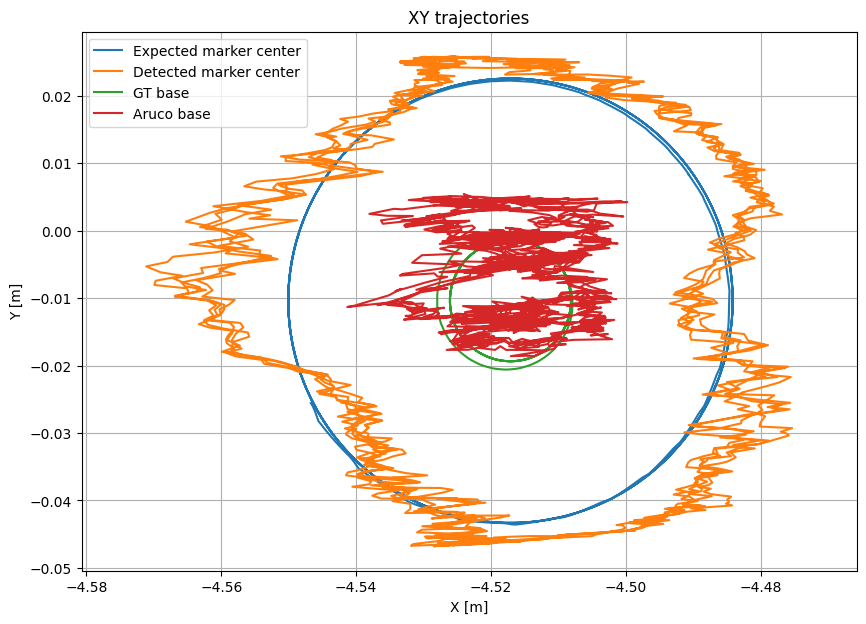

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

csv_path = "/home/katya/wspace/logs/aruco_odom_gt_0.csv"
marker_offset = 0.032
gap_threshold = 0.2

def wrap_to_pi(a):
    return (a + np.pi) % (2 * np.pi) - np.pi

def circular_mean(a):
    return np.arctan2(np.mean(np.sin(a)), np.mean(np.cos(a)))

def fit_2d_rigid_transform(x_src, y_src, x_dst, y_dst):
    src = np.column_stack([x_src, y_src])
    dst = np.column_stack([x_dst, y_dst])

    src_mean = src.mean(axis=0)
    dst_mean = dst.mean(axis=0)

    src_centered = src - src_mean
    dst_centered = dst - dst_mean

    H = src_centered.T @ dst_centered
    U, _, Vt = np.linalg.svd(H)
    R = Vt.T @ U.T

    if np.linalg.det(R) < 0:
        Vt[-1, :] *= -1
        R = Vt.T @ U.T

    t = dst_mean - R @ src_mean
    return R, t

def apply_2d_transform(x, y, R, t):
    pts = np.column_stack([x, y])
    pts_tf = (R @ pts.T).T + t
    return pts_tf[:, 0], pts_tf[:, 1]

def break_on_gaps(x, y, threshold):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    x_out = [x[0]]
    y_out = [y[0]]

    for i in range(1, len(x)):
        if (x[i] - x[i - 1]) > threshold:
            x_out.append(np.nan)
            y_out.append(np.nan)
        x_out.append(x[i])
        y_out.append(y[i])

    return np.array(x_out), np.array(y_out)

df = pd.read_csv(csv_path).dropna().reset_index(drop=True)

for col in ["odom_yaw", "aruco_yaw", "marker_center_yaw", "gt_yaw"]:
    df[col] = wrap_to_pi(df[col].values)

# отбрасываем стартовый переходный участок
df = df[df["t"] >= df["t"].min() + 2.0].copy().reset_index(drop=True)

# позиционное выравнивание odom -> gt
R_odom_to_gt, t_odom_to_gt = fit_2d_rigid_transform(
    df["odom_x"].values,
    df["odom_y"].values,
    df["gt_x"].values,
    df["gt_y"].values,
)

df["odom_x_aligned"], df["odom_y_aligned"] = apply_2d_transform(
    df["odom_x"].values,
    df["odom_y"].values,
    R_odom_to_gt,
    t_odom_to_gt,
)

# yaw: сначала грубое выравнивание через XY
theta_align_xy = np.arctan2(R_odom_to_gt[1, 0], R_odom_to_gt[0, 0])
odom_yaw_pre = wrap_to_pi(df["odom_yaw"] + theta_align_xy)

# потом убираем постоянный остаточный bias по yaw
yaw_bias = circular_mean(wrap_to_pi(odom_yaw_pre - df["gt_yaw"]))
df["odom_yaw_aligned"] = wrap_to_pi(odom_yaw_pre - yaw_bias)

print("theta_align_xy [rad] =", theta_align_xy)
print("theta_align_xy [deg] =", np.degrees(theta_align_xy))
print("yaw_bias [rad] =", yaw_bias)
print("yaw_bias [deg] =", np.degrees(yaw_bias))

# expected marker center from GT
df["marker_gt_x"] = df["gt_x"] - marker_offset * np.cos(df["gt_yaw"])
df["marker_gt_y"] = df["gt_y"] - marker_offset * np.sin(df["gt_yaw"])
df["marker_gt_yaw"] = df["gt_yaw"]

# errors
df["odom_err_pos"] = np.sqrt(
    (df["odom_x_aligned"] - df["gt_x"])**2 +
    (df["odom_y_aligned"] - df["gt_y"])**2
)
df["odom_err_yaw"] = np.abs(wrap_to_pi(df["odom_yaw_aligned"] - df["gt_yaw"]))

df["aruco_err_pos"] = np.sqrt(
    (df["aruco_x"] - df["gt_x"])**2 +
    (df["aruco_y"] - df["gt_y"])**2
)
df["aruco_err_yaw"] = np.abs(wrap_to_pi(df["aruco_yaw"] - df["gt_yaw"]))

df["marker_err_pos"] = np.sqrt(
    (df["marker_center_x"] - df["marker_gt_x"])**2 +
    (df["marker_center_y"] - df["marker_gt_y"])**2
)
df["marker_err_yaw"] = np.abs(wrap_to_pi(df["marker_center_yaw"] - df["marker_gt_yaw"]))

# break lines on time gaps
t_odom, odom_err_pos_plot = break_on_gaps(df["t"], df["odom_err_pos"], gap_threshold)
t_aruco, aruco_err_pos_plot = break_on_gaps(df["t"], df["aruco_err_pos"], gap_threshold)
t_marker, marker_err_pos_plot = break_on_gaps(df["t"], df["marker_err_pos"], gap_threshold)

_, odom_err_yaw_plot = break_on_gaps(df["t"], df["odom_err_yaw"], gap_threshold)
_, aruco_err_yaw_plot = break_on_gaps(df["t"], df["aruco_err_yaw"], gap_threshold)
_, marker_err_yaw_plot = break_on_gaps(df["t"], df["marker_err_yaw"], gap_threshold)

# graph 1
plt.figure(figsize=(12, 5))
plt.plot(t_odom, odom_err_pos_plot, label="Odometry")
plt.plot(t_aruco, aruco_err_pos_plot, label="Aruco base")
plt.plot(t_marker, marker_err_pos_plot, label="Marker center")
plt.axhline(0.0, linestyle="--", label="Ideal (0 error)")
plt.xlabel("Time [s]")
plt.ylabel("Error [m]")
plt.title("Position error vs Ground Truth")
plt.grid(True)
plt.legend()
plt.show()

# graph 2
plt.figure(figsize=(12, 5))
plt.plot(t_odom, odom_err_yaw_plot, label="Odometry")
plt.plot(t_aruco, aruco_err_yaw_plot, label="Aruco base")
plt.plot(t_marker, marker_err_yaw_plot, label="Marker center")
plt.axhline(0.0, linestyle="--", label="Ideal (0 error)")
plt.xlabel("Time [s]")
plt.ylabel("Error [rad]")
plt.title("Yaw error vs Ground Truth")
plt.grid(True)
plt.legend()
plt.show()

# graph 3
plt.figure(figsize=(10, 7))
plt.plot(df["marker_gt_x"], df["marker_gt_y"], label="Expected marker center")
plt.plot(df["marker_center_x"], df["marker_center_y"], label="Detected marker center")
plt.plot(df["gt_x"], df["gt_y"], label="GT base")
plt.plot(df["aruco_x"], df["aruco_y"], label="Aruco base")
plt.xlabel("X [m]")
plt.ylabel("Y [m]")
plt.title("XY trajectories")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()